This is an attempt of combining all of the features for classification.

In [62]:
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, LineString
from tqdm import tqdm
from scipy.spatial import ConvexHull
import math
import os
import json


ox.settings.use_cache = True
ox.settings.log_console = True

In [63]:
# place_name = "Manhattan, New York City, New York, USA"

# G = ox.graph_from_place(place_name, network_type="drive")
# G = ox.project_graph(G)
# gdf_nodes, gdf_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)

In [64]:
def calculate_boeing_features(G, Gu, min_length=0):
    """
    features:
        phi_orientation_order
        entropy_simplified
        entropy_weighted
        median_street_segment_length
        avg_circuity
        avg_node_degree
        p_dead_ends
        p_four_way
    """

    entropy_simplified = ox.bearing.orientation_entropy(G=Gu, num_bins=36, weight=None, min_length=min_length)
    entropy_weighted = ox.bearing.orientation_entropy(G=Gu, num_bins=36, weight="length", min_length=min_length)
    phi_orientation_order = 1 - (((entropy_simplified-1.386)/(3.584-1.386))**2)
    basic_stats = ox.stats.basic_stats(Gu)
    median_street_segment_length = basic_stats["street_length_avg"]
    avg_circuity = basic_stats["circuity_avg"]
    avg_node_degree = basic_stats["k_avg"]
    p_dead_ends = basic_stats["streets_per_node_proportions"][0]
    p_four_way = basic_stats["streets_per_node_proportions"][3]

    return {
        "selected_features" : {
            "phi_orientation_order": phi_orientation_order,
            "entropy_simplified": entropy_simplified,
            "entropy_weighted": entropy_weighted,
            "median_street_segment_length": median_street_segment_length,
            "avg_circuity": avg_circuity,
            "avg_node_degree": avg_node_degree,
            "p_dead_ends": p_dead_ends,
            "p_four_way": p_four_way
        },
        "basic_stats" : basic_stats
    }


In [65]:
def minimum_bounding_circle_area(polygon):
    points = np.array(polygon.exterior.coords)
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]

    def enclosing_circle(points):
        from scipy.spatial import distance_matrix

        dist_mat = distance_matrix(points, points)
        i, j = np.unravel_index(dist_mat.argmax(), dist_mat.shape)
        center = (points[i] + points[j]) / 2
        radius = np.linalg.norm(points[i] - center)
        return center, radius

    center, radius = enclosing_circle(hull_points)
    return np.pi * radius**2


def compute_shape_factor(blocks):
    block_data = []
    for block, area in tqdm(blocks):
        if not isinstance(block, Polygon):
            continue
        # circumscribed_circle_area = (
        # np.pi * (block.length / (2 * np.pi)) ** 2
        # )  # Approximate, a bit faster
        circumscribed_circle_area = minimum_bounding_circle_area(block)

        phi = area / circumscribed_circle_area if circumscribed_circle_area > 0 else 0
        block_data.append((area, phi))

    return np.array(block_data)


bin_ranges = [
    (0, 1e1, "[0 - 10)"),
    (1e1, 1e2, "[10 - 100)"),
    (1e2, 1e3, "[100 - 10^3)"),
    (1e3, 1e4, "[10^3 - 10^4)"),
    (1e4, 1e5, "[10^4 - 10^5)"),
    (1e5, 1e6, "[10^5 - 10^6)"),
    (1e6, 1e7, "[10^6 - 10^7)"),
    # (1e7, 0, "[10^7 - 0) (unused)"),
]

color_names = [
    "black",
    "gray",
    "brown",
    "#66C2A5",
    "#FC8D62",
    "#8DA0CB",
    "#E78AC3",
    "white",
]


def get_pd(block_data, city_name):
    if len(block_data) == 0:
        print(f"No valid blocks found for {city_name}")
        return

    # fig, ax = plt.subplots(figsize=(8, 5))

    # colors = color_names

    # bin_edges = np.linspace(0, 1, 51)  # 50 bins between 0 and 1
    bin_edges = np.linspace(0, 1, 31)  # seems to be different in different plots
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    total_blocks = len(block_data)

    total_hist = np.zeros_like(bin_centers)

    # number_of_blocks_by_shape_factor is just a histogram of the shape factors
    number_of_blocks_by_shape_factor = np.histogram(
        block_data[:, 1], bins=bin_edges, density=True
    )[0]

    weighted_hist_by_bin_ranges = np.zeros((len(bin_ranges), len(bin_centers)))

    for i, (a_min, a_max, b_label) in enumerate(bin_ranges):
        phi_values = block_data[
            (block_data[:, 0] >= a_min) & (block_data[:, 0] < a_max), 1
        ]
        n = len(phi_values)
        if n == 0:
            continue
        hist, _ = np.histogram(phi_values, bins=bin_edges, density=True)
        weighted_hist = hist * (n / total_blocks)
        weighted_hist_by_bin_ranges[i] = weighted_hist
        total_hist += weighted_hist
        # ax.plot(bin_centers, weighted_hist, color=colors[i], label=b_label)

    # ax.plot(
    #     bin_centers,
    #     total_hist,
    #     color="gray",
    #     linewidth=0.5,
    #     linestyle="--",
    # )
    # ax.fill_between(bin_centers, total_hist, color="gray", alpha=0.1)

    # ax.set_xlabel(r"$\Phi$", fontsize=14)
    # ax.set_ylabel(r"$f(\Phi)$", fontsize=14)
    # ax.set_title(f"{city_name}", fontsize=18, weight="bold")
    # ax.legend()
    # plt.tight_layout()
    # plt.show()
    return {
        "selected_features": {
            "total_hist": total_hist,
            "weighted_hist_by_bin_ranges": weighted_hist_by_bin_ranges,
        },
        "our_features": {
            "number_of_blocks": total_blocks,
            "number_of_blocks_by_shape_factor": number_of_blocks_by_shape_factor,
            "blocks_area": np.sum(block_data[:, 0]),
        },
    }


def calculate_lnb_features(G, gdf_nodes, place_name):
    """
    phi_shape_factor0, ..., phi_shape_factor29
    phi_by_log_area_2_3_0, ..., phi_by_log_area_2_3_29
    phi_by_log_area_3_4_0, ..., phi_by_log_area_3_4_29
    phi_by_log_area_4_5_0, ..., phi_by_log_area_4_5_29
    """

    blocks = []
    for cycle in tqdm(nx.cycle_basis(nx.Graph(G))):
        coords = [
            gdf_nodes.loc[node].geometry for node in cycle if node in gdf_nodes.index
        ]
        if len(coords) >= 3:
            poly = Polygon(coords)
            ogpoly = poly
            ogarea = poly.area
            # try:
            #     for i in range(len(coords) - 1):
            #         poly = poly.union(LineString([coords[i], coords[i + 1]]))
            # except Exception as e:
            #     # print(e)
            #     continue
            # narea = poly.area
            narea = ogarea
            # print(
            #     f"Original Area: {ogarea}, New Area: {narea}, Area Difference: {narea - ogarea}"
            # )
            if poly.is_valid:
                blocks.append((ogpoly, narea))
    # # plotting blocks
    # fig, ax = plt.subplots(figsize=(8, 8))
    # for block, area in blocks:
    #     x, y = block.exterior.xy
    #     ax.fill(x, y, alpha=0.5)
    # ax.set_aspect("equal", "datalim")
    # plt.title(f"Blocks of {place_name}")
    # # plt.savefig(f"louf_LVN_{ncname}_blocks.png")
    # plt.show()

    # calculate features
    return get_pd(
        compute_shape_factor(blocks), place_name)#, min_length=0.001)

In [66]:
# Our custom features
def calculate_min_zoom_level(place_name):
    # from OSM wiki on Zoom_levels - https://wiki.openstreetmap.org/wiki/Zoom_levels
    geocode_result = ox.geocode_to_gdf(place_name)
    if geocode_result is not None and not geocode_result.empty:
        lon_min, lat_min, lon_max, lat_max = geocode_result.total_bounds
        # projecting to crs
        utm_crs = ox.projection.project_gdf(geocode_result).crs
        geocode_result = geocode_result.to_crs(utm_crs)
        area = geocode_result.area[0]/10**6
        lat_span_km = (geocode_result.bounds.maxy[0] - geocode_result.bounds.miny[0])/1000
        lon_span_km = (geocode_result.bounds.maxx[0] - geocode_result.bounds.minx[0])/1000
        # print(f"area: {round(area, 2)} km^2, lat_span: {round(lat_span_km, 2)} km, lon_span: {round(lon_span_km, 2)} km")
        lond = abs(lon_max - lon_min)
        lon_level = 0
        for level in range(21, 0, -1):
            s = 360 / 2**level
            if s > lond:
                # return level
                lon_level = level
                break
        # geod = Geodesic.WGS84
        # g = geod.Inverse(lat_min, lon_min, lat_max, lon_min)
        # latd = g["s12"]  # N-S distance in meters
        latd = lat_max - lat_min
        lat_level = 0
        for level in range(21, 0, -1):
            s = 180 / 2**level
            if s > latd:
                # return level
                lat_level = level
                break
        return min(lon_level, lat_level), area, lat_span_km, lon_span_km, lat_level, lon_level, (lat_max + lat_min)/2, (lon_max + lon_min)/2
    else:
        raise ValueError("Place not found.")

def calculate_our_features(place_name):
    zoom, area, lat_span_km, lon_span_km, lat_level, lon_level, lat, lon = calculate_min_zoom_level(place_name)
    return {
        "zoom": zoom,
        "area_by_boundary": area,
        "span_lat": lat_span_km,
        "span_lon": lon_span_km,
        "zoom_lat": lat_level,
        "zoom_lon": lon_level,
        "lat": lat,
        "lon": lon,
    }


In [67]:
# combine all features
cities = [
    "Kyiv, Ukraine",
    "Honalulu, Hawaii",
    "Lviv, Ukraine",
    "Mombasa, Mvita, Mombasa County, Coast, Kenya",
    "Ivano-Frankivsk, Ivano-Frankivsk Oblast, Ukraine",
    "Santana, Cantagalo, São Tomé and Príncipe",
    "Kolomyia, Ukraine",
    "Drohobych, Ukraine",
    "Boryslav, Ukraine",
    "Mykolaiv, Lviv, Ukraine",
    "Perth, Australia",
    "Vynnyky, Ukraine",
    "Halytskyi District, Lviv, Ukraine",
    "Bibrka, Ukraine",
]

def convert_for_json(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    else:
        return obj

for city in cities:
    print(f"Calculating features for {city}")
    try:
        G = ox.graph_from_place(city, network_type="drive")
        Gu = ox.graph_from_place(city, network_type="drive", simplify=True)#, retain_all=True)
        ox.bearing.add_edge_bearings(Gu)
        Gu = ox.convert.to_undirected(Gu)
        G = ox.project_graph(G)
        gdf_nodes, gdf_edges = ox.graph_to_gdfs(G, nodes=True, edges=True)
        lnb_features = calculate_lnb_features(G, gdf_nodes, city)
        boeing_features = calculate_boeing_features(G, Gu)
        our_features = calculate_our_features(city)
        combined_features = {
            "lnb": lnb_features,
            "boeing": boeing_features,
            "our": our_features,
        }
        # print(combined_features)
        os.makedirs("results", exist_ok=True)
        filename = f"results/{city.replace(', ', '_').replace(' ', '_')}_features.json"

        # making it flat for csv
        # phi_orientation_order,
        # entropy_simplified,
        # entropy_weighted,
        # median_street_segment_length,
        # avg_circuity,
        # avg_node_degree,
        # p_dead_ends,
        # p_four_way,
        # phi_shape_factor0, ..., phi_shape_factor29,
        # phi_by_log_area_2_3_0, ..., phi_by_log_area_2_3_29,
        # phi_by_log_area_3_4_0, ..., phi_by_log_area_3_4_29,
        # phi_by_log_area_4_5_0, ..., phi_by_log_area_4_5_29,
        # zoom,
        # blocks_area,
        # span_lat,
        # span_lon,
        # number_of_blocks,
        # number_of_blocks_by_shape_factor0, ..., number_of_blocks_by_shape_factor29,
        # area_by_boundary,
        # latitude,
        # longitude,
        # zoom_lat,
        # zoom_lon

        flattened_features = [
            boeing_features["selected_features"]["phi_orientation_order"],
            boeing_features["selected_features"]["entropy_simplified"],
            boeing_features["selected_features"]["entropy_weighted"],
            boeing_features["selected_features"]["median_street_segment_length"],
            boeing_features["selected_features"]["avg_circuity"],
            boeing_features["selected_features"]["avg_node_degree"],
            boeing_features["selected_features"]["p_dead_ends"],
            boeing_features["selected_features"]["p_four_way"],
        ]
        
        for i in lnb_features["selected_features"]["total_hist"]:
            flattened_features.append(i)

        for i in lnb_features["selected_features"]["weighted_hist_by_bin_ranges"][2]:
            flattened_features.append(i)
        for i in lnb_features["selected_features"]["weighted_hist_by_bin_ranges"][3]:
            flattened_features.append(i)
        for i in lnb_features["selected_features"]["weighted_hist_by_bin_ranges"][4]:
            flattened_features.append(i)
        
        flattened_features.append(our_features["zoom"])
        flattened_features.append(lnb_features["our_features"]["blocks_area"])
        flattened_features.append(our_features["span_lat"])
        flattened_features.append(our_features["span_lon"])
        flattened_features.append(lnb_features["our_features"]["number_of_blocks"])
        for i in lnb_features["our_features"]["number_of_blocks_by_shape_factor"]:
            flattened_features.append(i)
        
        flattened_features.append(our_features["area_by_boundary"])
        flattened_features.append(our_features["lat"])
        flattened_features.append(our_features["lon"])
        flattened_features.append(our_features["zoom_lat"])
        flattened_features.append(our_features["zoom_lon"])

        with open(filename.replace(".json", ".csv"), "w") as f:
            f.write(",".join([str(i) for i in flattened_features]) + "\n")
        
        with open(filename, "w") as f:
            # converting to json properly
            json_ready = convert_for_json(combined_features)
            json.dump(json_ready, f, indent=4)
    except Exception as e:
        print(f"Error calculating features for {city}: {e}")

Calculating features for Kyiv, Ukraine


100%|██████████| 3623/3623 [00:02<00:00, 1252.31it/s]
C:\Users\Max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\osmnx\convert.py:541: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  dupes = edges[mask].dropna(subset=["geometry"])


Calculating features for Honalulu, Hawaii


100%|██████████| 1924/1924 [00:01<00:00, 1353.12it/s]
C:\Users\Max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\osmnx\convert.py:541: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  dupes = edges[mask].dropna(subset=["geometry"])


Calculating features for Lviv, Ukraine


...

100%|██████████| 82/82 [00:00<00:00, 691.83it/s]
C:\Users\Max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\osmnx\convert.py:541: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  dupes = edges[mask].dropna(subset=["geometry"])


Calculating features for Halytskyi District, Lviv, Ukraine


100%|██████████| 202/202 [00:00<00:00, 1111.40it/s]
C:\Users\Max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\osmnx\convert.py:541: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  dupes = edges[mask].dropna(subset=["geometry"])


Calculating features for Bibrka, Ukraine


100%|██████████| 25/25 [00:00<00:00, 526.05it/s]
C:\Users\Max\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\osmnx\convert.py:541: FutureWarning: <class 'geopandas.array.GeometryArray'>._reduce will require a `keepdims` parameter in the future
  dupes = edges[mask].dropna(subset=["geometry"])


C:\Users\Max\AppData\Local\Temp\ipykernel_36172\659234761.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Accent", k)


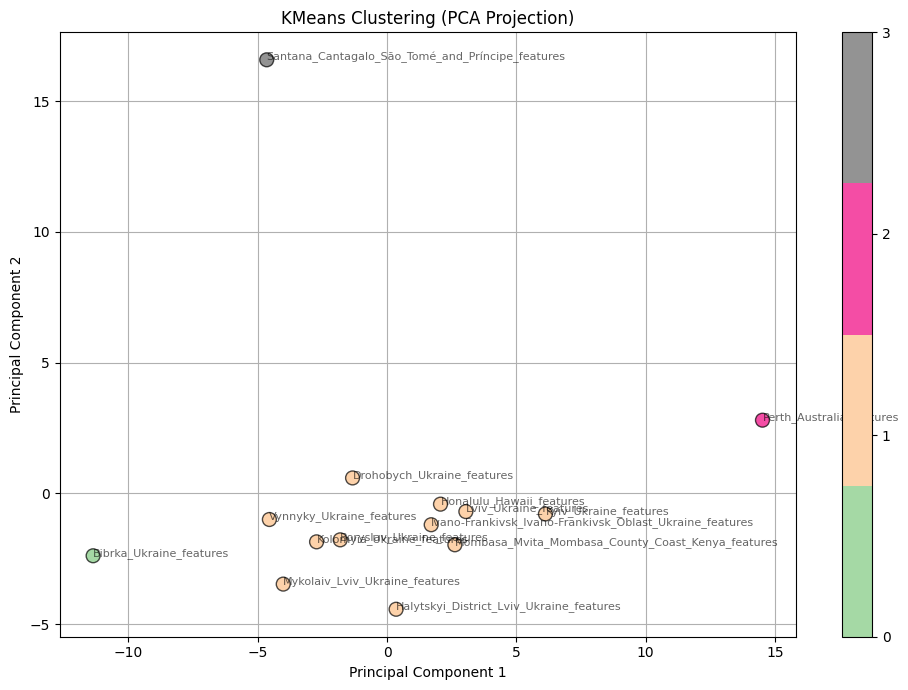

              0         1         2           3         4         5    6    \
cluster                                                                      
0        0.411647  3.071957  3.123479  130.983132  1.073619  2.366197  0.0   
1        0.081264  3.491715  3.485873  157.551906  1.062739  2.651311  0.0   
2        0.250827  3.288474  3.203695   93.342816  1.038795  3.105627  0.0   
3        0.066551  3.509601  3.387456  482.947620  1.266658  2.345455  0.0   

              7         8         9    ...       158       159  160  161  162  \
cluster                                ...                                      
0        0.633803  0.000000  0.000000  ...  0.000000  0.000000  0.0  0.0  0.0   
1        0.674630  0.236198  0.394396  ...  0.006957  0.000000  0.0  0.0  0.0   
2        0.674235  0.674157  1.887640  ...  0.134831  0.202247  0.0  0.0  0.0   
3        0.645455  0.000000  0.000000  ...  0.000000  0.000000  0.0  0.0  0.0   

                163        164         165  

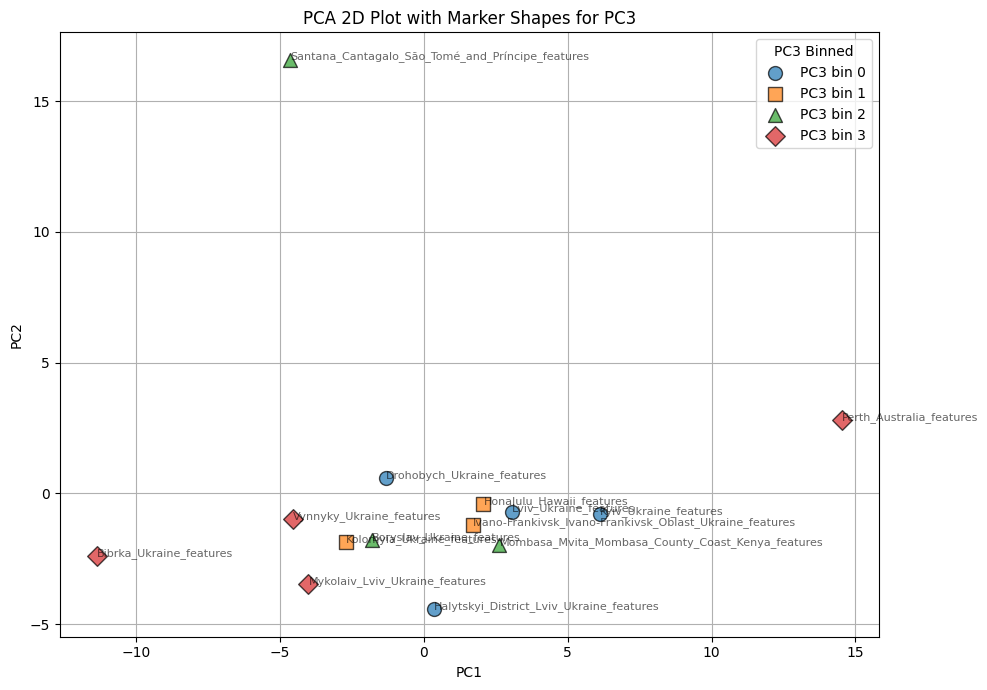

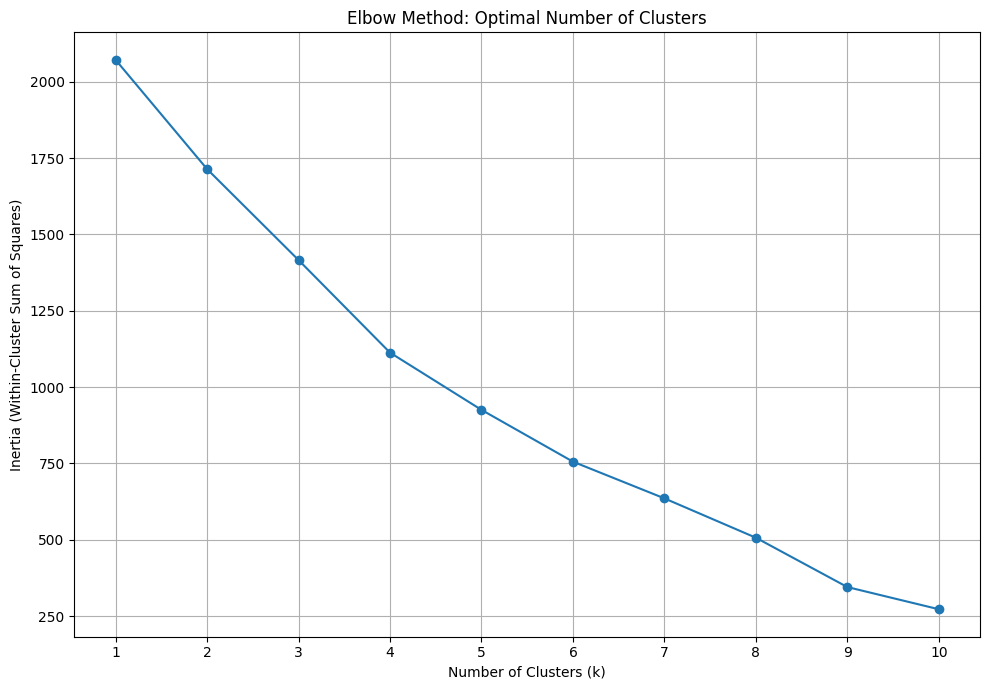

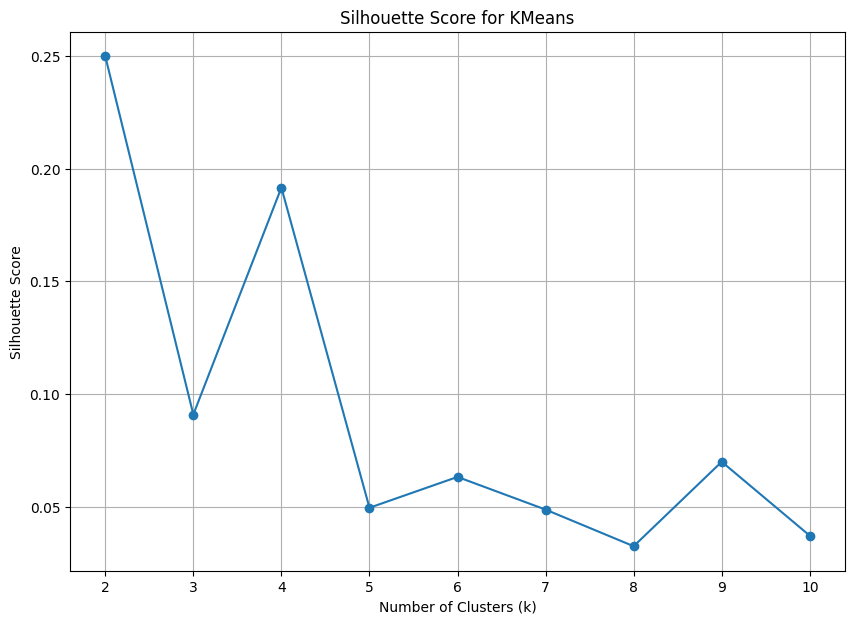

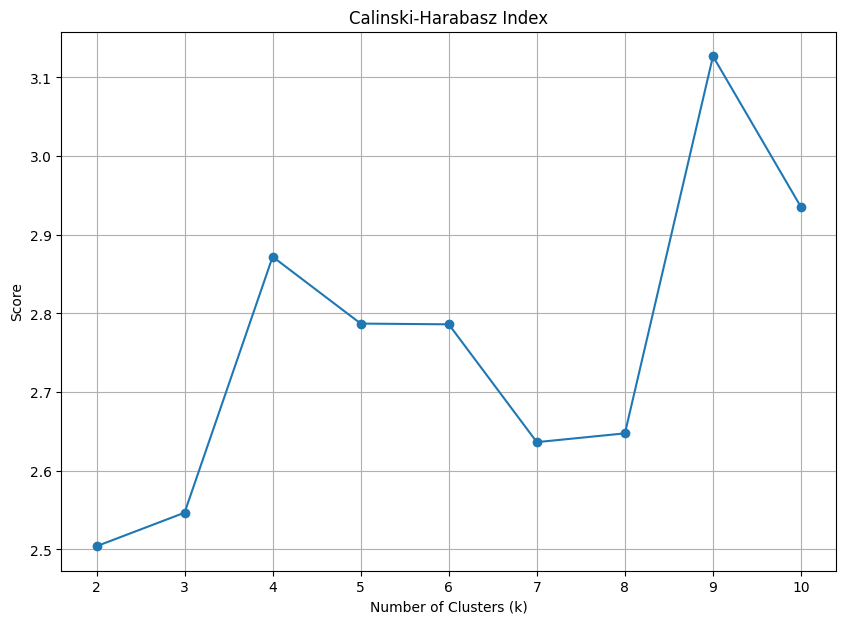

In [ ]:
import pandas as pd
import glob
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

rndstate = 20250405
ninits = 5

shape_factors = [f"phi_shape_factor{i}" for i in range(30)]
phi_area_bins = []
for bin_label in ["2_3", "3_4", "4_5"]:
    phi_area_bins.extend([f"phi_log_area_{bin_label}_{i}" for i in range(30)])
block_shape_counts = [f"n_blocks_by_shape_factor{i}" for i in range(30)]

feature_columns = [
    "phi_orientation_order",
    "entropy_simplified",
    "entropy_weighted",
    "median_street_segment_length",
    "avg_circuity",
    "avg_node_degree",
    "p_dead_ends",
    "p_four_way",
    *shape_factors,
    *phi_area_bins,
    "zoom",
    "blocks_area",
    "span_lat",
    "span_lon",
    "number_of_blocks",
    *block_shape_counts,
    "area_by_boundary",
    "latitude",
    "longitude",
    "zoom_lat",
    "zoom_lon",
]

csv_files = glob.glob("results/*.csv")
city_names = [os.path.splitext(os.path.basename(f))[0] for f in csv_files]
df_list = []
for f, name in zip(csv_files, city_names):
    row = pd.read_csv(f, header=None)
    row["city_name"] = name
    df_list.append(row)
df = pd.concat(df_list, ignore_index=True)
data = df.drop(columns=["city_name"])
data.columns = feature_columns

# Normalizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# Clustering
k = 4  # seems to be a good enough number
kmeans = KMeans(n_clusters=k, init="k-means++", random_state=rndstate, n_init=ninits)
labels = kmeans.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
cmap = cm.get_cmap("Accent", k)
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=labels, cmap=cmap, edgecolor="#000", s=100, alpha=0.7
)

for i, name in enumerate(df["city_name"]):
    plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.6)

plt.title("KMeans Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, ticks=range(k))
plt.grid(True)
plt.tight_layout()
plt.show()

df["cluster"] = labels
df.to_csv("clustered_cities.csv", index=False)

cluster_summary = df.groupby("cluster").mean(numeric_only=True)
print(cluster_summary)


# Experiments on 3d here
pca = PCA(n_components=3)
X_pca_3 = pca.fit_transform(X_scaled)
num_shapes = 4
z_bins = pd.qcut(X_pca_3[:, 2], q=num_shapes, labels=False)
marker_styles = ["o", "s", "^", "D"]  # circle, square, triangle, diamond
plt.figure(figsize=(10, 7))
for i, name in enumerate(df["city_name"]):
    plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.6)
for shape_idx in range(num_shapes):
    idx = np.where(z_bins == shape_idx)
    plt.scatter(
        X_pca_3[idx, 0],
        X_pca_3[idx, 1],
        marker=marker_styles[shape_idx],
        label=f"PC3 bin {shape_idx}",
        edgecolor="#000",
        s=100,
        alpha=0.7,
    )
plt.title("PCA 2D Plot with Marker Shapes for PC3")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, ticks=range(k))
plt.grid(True)
plt.tight_layout()
plt.legend(title="PC3 Binned")
plt.show()


# Trying to find the best number of clusters
k_range = range(1, 11)
inertias = []
for k in k_range:
    kmeans = KMeans(
        n_clusters=k, init="k-means++", random_state=rndstate, n_init=ninits
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 7))
plt.plot(k_range, inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

# ===
from sklearn.metrics import silhouette_score

scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(
        n_clusters=k, init="k-means++", random_state=rndstate, n_init=ninits
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.figure(figsize=(10, 7))
plt.plot(k_range, scores, marker="o")
plt.title("Silhouette Score for KMeans")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# ===
from sklearn.metrics import calinski_harabasz_score

ch_scores = []
for k in k_range:
    kmeans = KMeans(
        n_clusters=k, init="k-means++", random_state=rndstate, n_init=ninits
    )
    labels = kmeans.fit_predict(X_scaled)
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

plt.figure(figsize=(10, 7))
plt.plot(k_range, ch_scores, marker="o")
plt.title("Calinski-Harabasz Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)
plt.show()